# 07. Лёгкий «табличный» трансформер

## Почему «табличный» трансформер

Признаки трактуются как **последовательность длины** `n_features` (после `Reshape` в «псевдотокены»), дальше — проекция в `d_model`, один слой **Multi-Head Attention**, нормализация, **GlobalAveragePooling** по длине последовательности и плотный классификатор. **Позиционного кодирования** как в NLP нет: **порядок признаков** задаётся лишь индексом во входном векторе.

In [1]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix
import seaborn as sns
from helpers import load_xy_from_processed, classification_metrics_dict, print_report, append_metrics_store, PLOT_DIR, CLASS_NAMES, RANDOM_STATE

2026-04-24 22:51:51.045898: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 22:51:51.045941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 22:51:51.046943: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

X_train, X_val, X_test, y_train, y_val, y_test, _ = load_xy_from_processed()
n_feat = X_train.shape[1]
n_classes = len(CLASS_NAMES)
d_model = 32


inputs = keras.Input(shape=(n_feat,))
x = keras.layers.Reshape((n_feat, 1))(inputs)
x = keras.layers.Dense(d_model)(x)
x = keras.layers.MultiHeadAttention(num_heads=4, key_dim=8)(x, x)
x = keras.layers.LayerNormalization()(x)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(64, activation='relu')(x)
out = keras.layers.Dense(n_classes, activation='softmax')(x)

model = keras.Model(inputs, out)

In [5]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 reshape (Reshape)           (None, 8, 1)                 0         ['input_1[0][0]']             
                                                                                                  
 dense (Dense)               (None, 8, 32)                64        ['reshape[0][0]']             
                                                                                                  
 multi_head_attention (Mult  (None, 8, 32)                4224      ['dense[0][0]',               
 iHeadAttention)                                                     'dense[0][0]']           

## Конфиг

Запишите в тексте: `d_model`, число голов `num_heads`, `key_dim`, а также `epochs` и `batch_size` — эти величины вместе определяют ёмкость и стоимость эпохи.

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cb = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss')
]

h = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64, callbacks=cb, verbose=1)

Epoch 1/100
88/88 [==============================] - 1s 5ms/step - loss: 1.2722 - accuracy: 0.3679 - val_loss: 1.2046 - val_accuracy: 0.4133
Epoch 2/100
88/88 [==============================] - 0s 3ms/step - loss: 1.2075 - accuracy: 0.3984 - val_loss: 1.1689 - val_accuracy: 0.4225
Epoch 3/100
88/88 [==============================] - 0s 3ms/step - loss: 1.1900 - accuracy: 0.4064 - val_loss: 1.1575 - val_accuracy: 0.4225
Epoch 4/100
88/88 [==============================] - 0s 3ms/step - loss: 1.1631 - accuracy: 0.4187 - val_loss: 1.1175 - val_accuracy: 0.4342
Epoch 5/100
88/88 [==============================] - 0s 3ms/step - loss: 1.1179 - accuracy: 0.4259 - val_loss: 1.0466 - val_accuracy: 0.4933
Epoch 6/100
88/88 [==============================] - 0s 3ms/step - loss: 1.0547 - accuracy: 0.4855 - val_loss: 1.0231 - val_accuracy: 0.5092
Epoch 7/100
88/88 [==============================] - 0s 3ms/step - loss: 1.0306 - accuracy: 0.4968 - val_loss: 1.0173 - val_accuracy: 0.5033
Epoch 8/100
8

In [8]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
m = classification_metrics_dict(y_test, y_pred)
print(m); print_report(y_test, y_pred)

{'accuracy': 0.6066666666666667, 'precision_macro': 0.6138050260174668, 'recall_macro': 0.6066666666666667, 'f1_macro': 0.6056660605969143, 'precision_micro': 0.6066666666666667, 'recall_micro': 0.6066666666666667, 'f1_micro': 0.6066666666666667}
              precision    recall  f1-score   support

    OPEN_SEA       0.72      0.83      0.77       300
 COASTAL_SEA       0.46      0.42      0.44       300
  NEAR_COAST       0.48      0.56      0.51       300
   COASTLINE       0.79      0.62      0.70       300

    accuracy                           0.61      1200
   macro avg       0.61      0.61      0.61      1200
weighted avg       0.61      0.61      0.61      1200



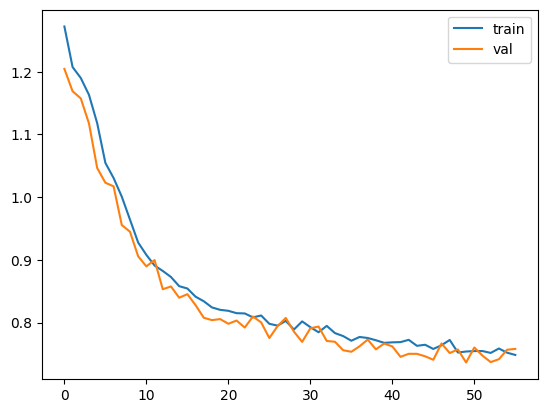

In [9]:
append_metrics_store('transformer', m)

plt.figure()
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')
plt.legend()
plt.savefig(PLOT_DIR / 'transformer_loss.png', dpi=150)
plt.show()
plt.close()

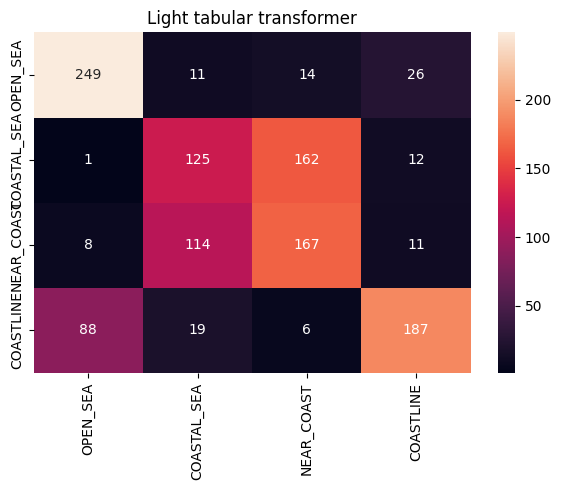

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Light tabular transformer')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_transformer.png', dpi=150)
plt.show()
plt.close()